# WGAN — Wasserstein GAN

This notebook implements the original **Wasserstein GAN** (Arjovsky et al., 2017), following Module 11. The original GAN minimizes a value function tied to **JS divergence**. WGAN replaces that with the **Wasserstein-1 distance** — also known as **Earth Mover's Distance (EMD)**.

The key conceptual changes:

- **Discriminator → Critic**: outputs a real-valued score, not a probability
- **No sigmoid** at the critic's output
- **No BCE loss** — directly optimize the Wasserstein estimate
- **Critic must be 1-Lipschitz** — original WGAN enforces this with **weight clipping**
- **Multiple critic updates per generator update** — typically `n_critic = 5`
- **RMSProp** optimizer (not Adam), as in the original paper

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)
np.random.seed(42)

## 1. Setup and Hyperparameters

The original WGAN paper used **RMSProp** (not Adam) with a small learning rate. Adam's momentum-based updates can interact poorly with the WGAN objective, so the paper explicitly recommended against it.

Other defaults follow the paper:

- `lr = 5e-5`
- `n_critic = 5` — critic updates per generator update
- `clip_value = 0.01` — weight clipping range

Why `n_critic = 5`? Because the Generator needs a well-trained Critic to provide useful gradients. If the Critic hasn't learned enough, its scores are meaningless and the Generator learns from noise.

In [2]:
latent_dim    = 100
img_channels  = 1
img_size      = 64
features_g    = 64
features_c    = 64   # base width of the Critic
batch_size    = 64
lr            = 5e-5
epochs        = 25
n_critic      = 5    # critic updates per generator update
clip_value    = 0.01 # weight clipping range for the Lipschitz constraint

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

os.makedirs('samples_WGAN', exist_ok=True)

Using device: cuda


## 2. Data — MNIST upscaled to 64×64

Same setup as DCGAN. We keep data normalized to $[-1, +1]$ so the Generator's `Tanh` output matches.

In [3]:
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

## 3. Weight Initialization

Same DCGAN-style init: $\mathcal{N}(0, 0.02)$ for Conv weights, $\mathcal{N}(1, 0.02)$ for BatchNorm weights, BatchNorm biases at $0$.

In [4]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## 4. The Critic (formerly the Discriminator)

The Critic takes an image and outputs an **unrestricted real-valued score**. There is **no `Sigmoid` at the end** — the output is a scalar, not a probability.

We also **do not use BatchNorm in the Critic**. This is a deliberate WGAN-paper choice: BatchNorm creates correlations between samples in the same minibatch, which interferes with the assumptions behind the Wasserstein estimate.

Spatial flow:

```
64 × 64  →  32 × 32  →  16 × 16  →  8 × 8   →  4 × 4   →  1
   1         64          128         256        512       1
```

Same architecture as DCGAN's Discriminator — just no BatchNorm and no Sigmoid.

In [5]:
class Critic(nn.Module):
    def __init__(self, img_channels=1, features_c=64):
        super().__init__()
        self.net = nn.Sequential(
            # 64 -> 32
            nn.Conv2d(img_channels, features_c, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 -> 16, NO BatchNorm
            nn.Conv2d(features_c, features_c * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 -> 8
            nn.Conv2d(features_c * 2, features_c * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 -> 4
            nn.Conv2d(features_c * 4, features_c * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 4 -> 1 (real-valued score)
            nn.Conv2d(features_c * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            # No Sigmoid — output is an unconstrained real number
        )

    def forward(self, x):
        return self.net(x).view(x.size(0), -1)

## 5. The Generator

Same architecture as DCGAN's Generator: `ConvTranspose2d` → `BatchNorm` → `ReLU` blocks, ending in `Tanh`. Only the training procedure changed in WGAN.

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_channels=1, features_g=64):
        super().__init__()
        self.net = nn.Sequential(
            # 1 -> 4
            nn.ConvTranspose2d(latent_dim, features_g * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),

            # 4 -> 8
            nn.ConvTranspose2d(features_g * 8, features_g * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            # 8 -> 16
            nn.ConvTranspose2d(features_g * 4, features_g * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            # 16 -> 32
            nn.ConvTranspose2d(features_g * 2, features_g, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            # 32 -> 64, Tanh
            nn.ConvTranspose2d(features_g, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z.view(z.size(0), z.size(1), 1, 1))

## 6. Models and Optimizers

We use **RMSProp** with `lr = 5e-5`. The original WGAN paper used this and explicitly recommended against Adam-style optimizers for WGAN.

In [7]:
C = Critic(img_channels=img_channels, features_c=features_c).to(device)
G = Generator(latent_dim=latent_dim, img_channels=img_channels, features_g=features_g).to(device)

C.apply(weights_init)
G.apply(weights_init)

optimizer_C = optim.RMSprop(C.parameters(), lr=lr)
optimizer_G = optim.RMSprop(G.parameters(), lr=lr)

print(C)
print()
print(G)

Critic(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)

## 7. The Training Loop

Two key differences from DCGAN:

1. **`n_critic = 5`** — train the Critic 5 times for every 1 Generator update. The Critic must converge (approximately) on the current Generator before being used to update it.
2. **Weight clipping** — after each Critic update, clamp every parameter to $[-0.01, 0.01]$. This is the original WGAN paper's crude way of enforcing the 1-Lipschitz constraint.

The losses are direct translations of the Wasserstein estimate:

- **Critic loss**: $L_C = E_{x \sim p_g}[f(x)] - E_{x \sim p_{data}}[f(x)]$
  - Minimized → equivalent to maximizing $W(p_{data}, p_g)$.
- **Generator loss**: $L_G = -E_z[f(G(z))]$
  - Minimized → pushes critic scores on fakes upward.

The number we plot is the **Wasserstein distance estimate** $\hat{W} = E[f(x_{real})] - E[f(x_{fake})]$. When this approaches 0, the distributions are getting closer.

In [8]:
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

w_distances = []
losses_g    = []

G.train()
C.train()

for epoch in range(epochs):
    epoch_w     = 0.0
    epoch_g     = 0.0
    n_batches   = 0

    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)

        # -----------------
        # Phase A: Train Critic (n_critic times)
        # -----------------
        for _ in range(n_critic):
            optimizer_C.zero_grad()

            # Real images
            real_score = C(real_imgs)

            # Fake images, detached so the Generator receives no gradient here
            z = torch.randn(b, latent_dim, 1, 1, device=device)
            with torch.no_grad():
                gen_imgs = G(z)
            fake_score = C(gen_imgs)

            # Wasserstein estimate: E[f(real)] - E[f(fake)]
            w_estimate = real_score.mean() - fake_score.mean()

            # Critic wants to maximize W, so minimize -W
            c_loss = -w_estimate
            c_loss.backward()
            optimizer_C.step()

            # Weight clipping — enforce the 1-Lipschitz constraint crudely
            for p in C.parameters():
                p.data.clamp_(-clip_value, clip_value)

        # -----------------
        # Phase B: Train Generator (once)
        # -----------------
        optimizer_G.zero_grad()

        gen_imgs    = G(z)               # NO detach — gradient flows through C into G
        validity    = C(gen_imgs)
        g_loss      = -validity.mean()   # want C to give high scores to our fakes
        g_loss.backward()
        optimizer_G.step()

        epoch_w += w_estimate.item()
        epoch_g += g_loss.item()
        n_batches += 1

    avg_w = epoch_w / n_batches
    avg_g = epoch_g / n_batches
    w_distances.append(avg_w)
    losses_g.append(avg_g)

    print(f"Epoch [{epoch+1}/{epochs}]  W-estimate: {avg_w:.4f}  G: {avg_g:.4f}")

    # Save a sample grid every epoch
    G.eval()
    with torch.no_grad():
        sample_imgs = G(fixed_noise).detach().cpu()
    save_image(sample_imgs, f"samples_WGAN/epoch_{epoch+1:02d}.png", nrow=8, normalize=True)
    G.train()

print('Training done.')

Epoch [1/25]  W-estimate: 473.4277  G: -1912.0954
Epoch [2/25]  W-estimate: 307.0631  G: -848.9028
Epoch [3/25]  W-estimate: 36.7595  G: -98.4273
Epoch [4/25]  W-estimate: 16.1177  G: -69.8328
Epoch [5/25]  W-estimate: 10.9852  G: -69.7898
Epoch [6/25]  W-estimate: 11.3892  G: -54.4539
Epoch [7/25]  W-estimate: 8.5112  G: -46.3603
Epoch [8/25]  W-estimate: 7.4307  G: -45.5472
Epoch [9/25]  W-estimate: 6.3831  G: -45.1221
Epoch [10/25]  W-estimate: 5.9540  G: -43.7751
Epoch [11/25]  W-estimate: 5.7631  G: -40.4850
Epoch [12/25]  W-estimate: 5.4693  G: -34.0733
Epoch [13/25]  W-estimate: 6.3628  G: -33.3614
Epoch [14/25]  W-estimate: 6.8033  G: -36.8491
Epoch [15/25]  W-estimate: 6.4741  G: -32.2583
Epoch [16/25]  W-estimate: 6.9167  G: -36.1266
Epoch [17/25]  W-estimate: 7.3479  G: -39.5774
Epoch [18/25]  W-estimate: 7.3283  G: -40.4135
Epoch [19/25]  W-estimate: 8.2015  G: -45.1304
Epoch [20/25]  W-estimate: 8.3029  G: -39.1632
Epoch [21/25]  W-estimate: 8.5953  G: -39.8061
Epoch [22/2

## 8. Generating New Samples

The Generator architecture is the same as DCGAN. Only the training procedure changed.

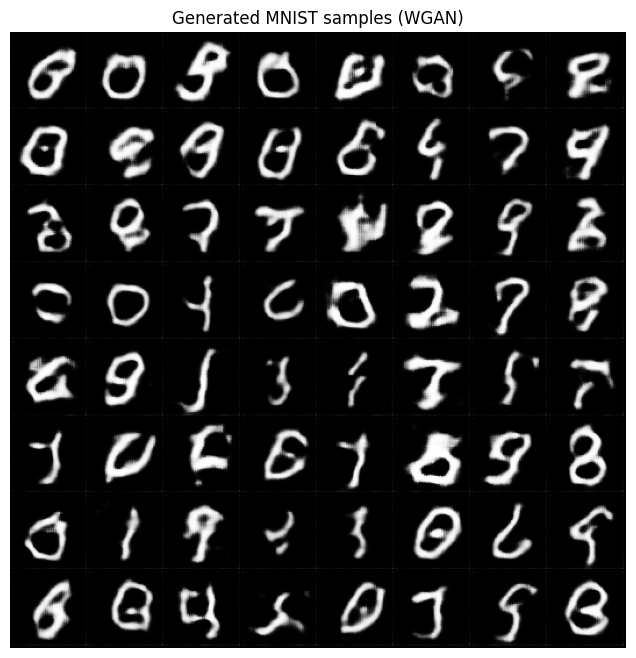

In [9]:
G.eval()
with torch.no_grad():
    samples = G(torch.randn(64, latent_dim, 1, 1, device=device)).cpu()

grid = make_grid(samples, nrow=8, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Generated MNIST samples (WGAN)')
plt.show()

## 9. Training Progression

Read each saved grid in order to see how the Generator's output evolves.

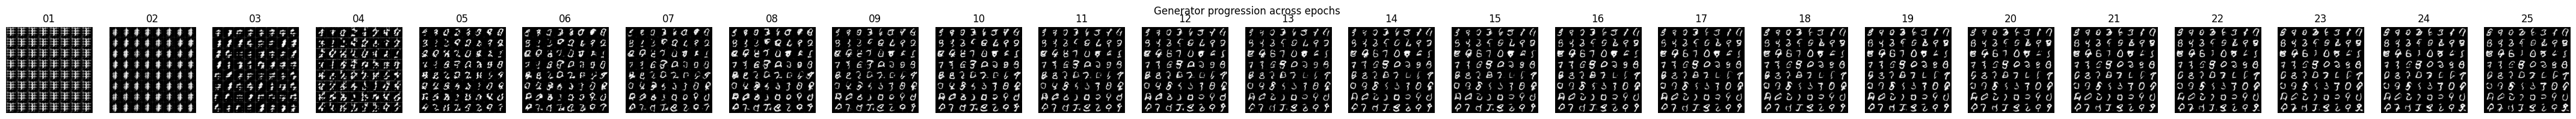

In [13]:
from PIL import Image
import glob

paths = sorted(glob.glob('samples_WGAN/epoch_*.png'))
if paths:
    fig, axes = plt.subplots(1, len(paths), figsize=(2.2 * len(paths), 2.2))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        ax.imshow(np.array(Image.open(p)).squeeze(), cmap='gray')
        ax.set_title(p.split('_')[-1].split('.')[0])
        ax.axis('off')
    plt.suptitle('Generator progression across epochs')
    plt.show()
else:
    print('No sample grids found. Run the training cell first.')

## 10. Loss Curves — Now Meaningful

One of WGAN's biggest practical wins: the Critic's output approximates the **Wasserstein distance** between $p_g$ and $p_{data}$. So the loss curve is more informative than vanilla GAN — when $\hat{W} \to 0$, the distributions are getting closer.

But don't take this as an absolute image-quality score — it's still a *training diagnostic*.

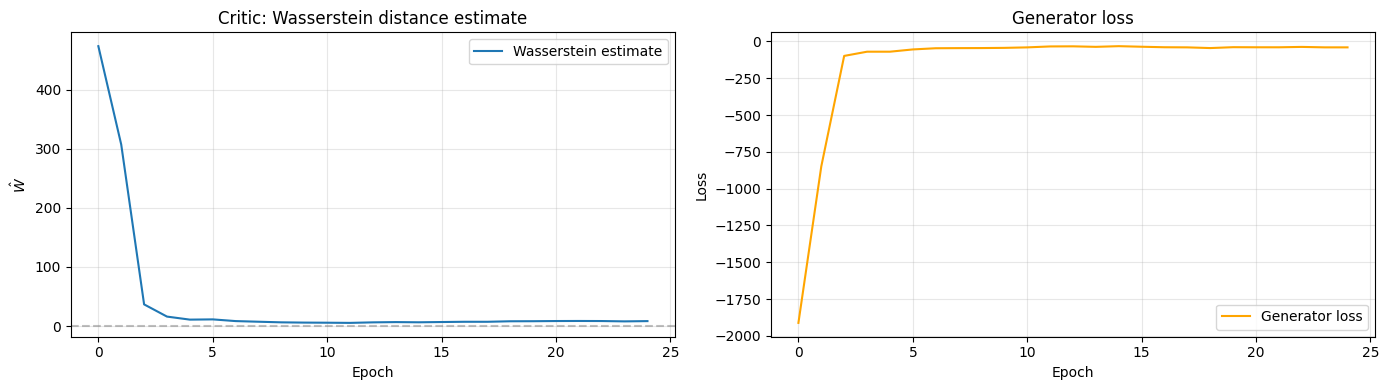

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(w_distances, label='Wasserstein estimate')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel(r'$\hat{W}$')
axes[0].set_title('Critic: Wasserstein distance estimate')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(losses_g, label='Generator loss', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Generator loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Recap — How WGAN Differs From DCGAN

| Concern | DCGAN | WGAN |
|---|---|---|
| Network | Discriminator | **Critic** |
| Output | probability (sigmoid) | **real-valued score** |
| Loss | `BCEWithLogitsLoss` | **direct Wasserstein estimate** |
| Normalization in critic | BatchNorm | **no BatchNorm** (correlations break W estimate) |
| Constraint | none | **weight clipping** to enforce 1-Lipschitz |
| Updates per G step | 1D : 1G | **5C : 1G** (typical) |
| Optimizer | Adam | **RMSProp** (paper recommendation) |
| LR | 2e-4 | **5e-5** |
| Loss interpretation | hard to read | approximates **Wasserstein distance** |

Same Generator, same `detach()` discipline, same alternating structure — but the training signal is now a meaningful distribution distance rather than a binary classification score.

**Next**: Module 12 replaces the crude weight clipping with a proper **gradient penalty**, giving us **WGAN-GP** — more stable, less hyperparameter-sensitive.

In [12]:
import zipfile
import os
from google.colab import files

# Define the directory to be zipped
directory_to_zip = 'samples_WGAN'
zip_file_name = f'{directory_to_zip}.zip'

# Create a ZipFile object
with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_dir in os.walk(directory_to_zip):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            # Add file to zip, preserving directory structure
            zipf.write(file_path, os.path.relpath(file_path, directory_to_zip))

print(f"'{directory_to_zip}' has been successfully zipped into '{zip_file_name}'")

# Offer the zip file for download
files.download(zip_file_name)

'samples_WGAN' has been successfully zipped into 'samples_WGAN.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>